In [336]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [337]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [338]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='lmars23', repo_name='ml_assignment_1', mlflow=True)

Initialized MLflow to track repo "lmars23/ml_assignment_1"

Repository lmars23/ml_assignment_1 initialized!

In [339]:
print(mlflow.get_tracking_uri())

https://dagshub.com/lmars23/ml_assignment_1.mlflow


# Exploratory Data Analysis (EDA)

In [340]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [341]:
df.head()
df.shape

(1460, 81)

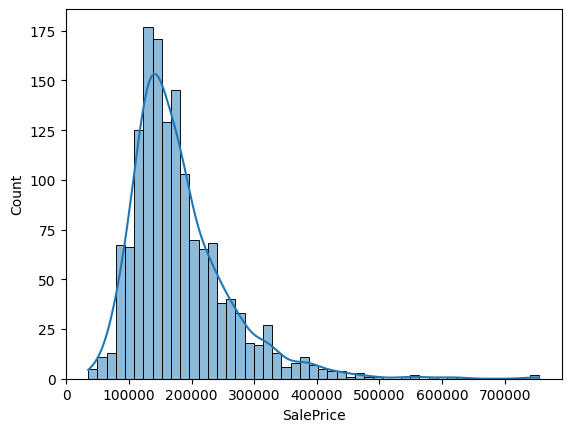

In [342]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.show()

In [343]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = np.log1p(df["SalePrice"])

y.describe()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1168, 80)
Test size:  (292, 80)


<Axes: >

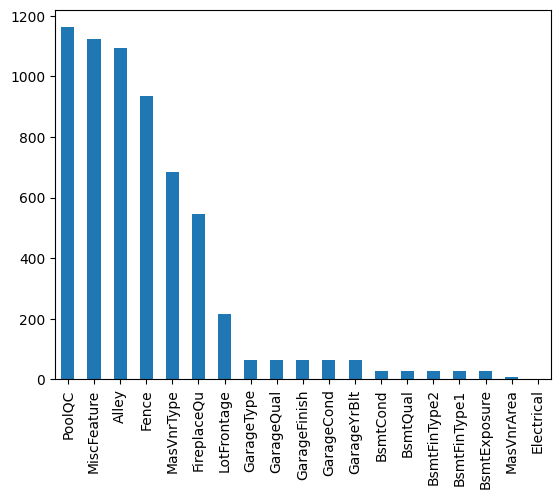

In [344]:
missing = X_train.isnull().sum().sort_values(ascending=False)

missing[missing > 0].plot(kind="bar")

In [345]:
missing_freq = X_train.isnull().mean() 
missing_freq[missing_freq > 0].sort_values(ascending=True)

Electrical      0.000856
MasVnrArea      0.005137
BsmtCond        0.023973
BsmtExposure    0.023973
BsmtFinType1    0.023973
BsmtQual        0.023973
BsmtFinType2    0.023973
GarageType      0.054795
GarageQual      0.054795
GarageFinish    0.054795
GarageCond      0.054795
GarageYrBlt     0.054795
LotFrontage     0.185788
FireplaceQu     0.468322
MasVnrType      0.584760
Fence           0.800514
Alley           0.936644
MiscFeature     0.960616
PoolQC          0.994863
dtype: float64

In [346]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'Gar

In [347]:
missing_freq_num = X_train[num_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

MasVnrArea     0.005137
GarageYrBlt    0.054795
LotFrontage    0.185788
dtype: float64

<Axes: >

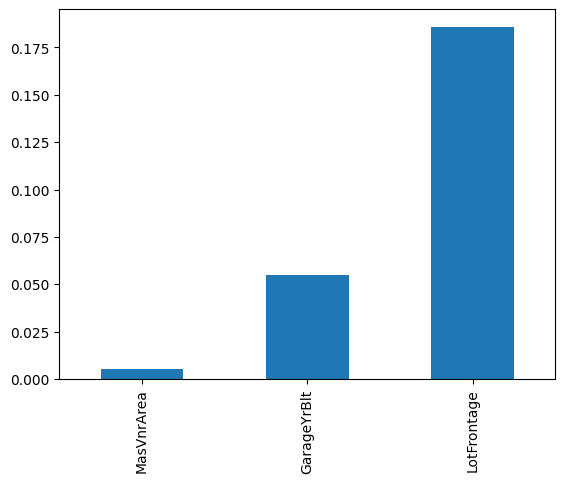

In [348]:
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True).plot(kind="bar")

<Axes: >

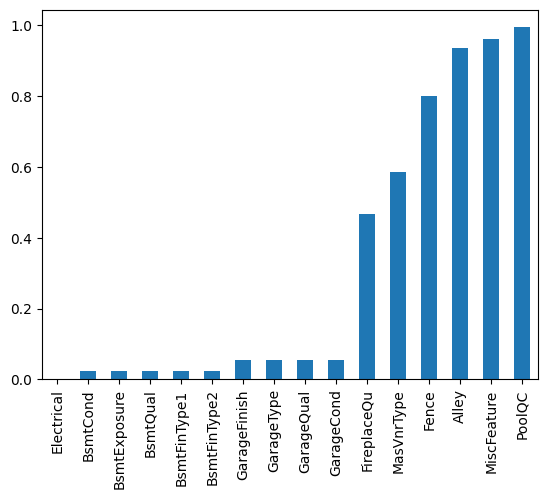

In [349]:
missing_freq_num = X_train[cat_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True).plot(kind="bar")

<Figure size 1500x1000 with 0 Axes>

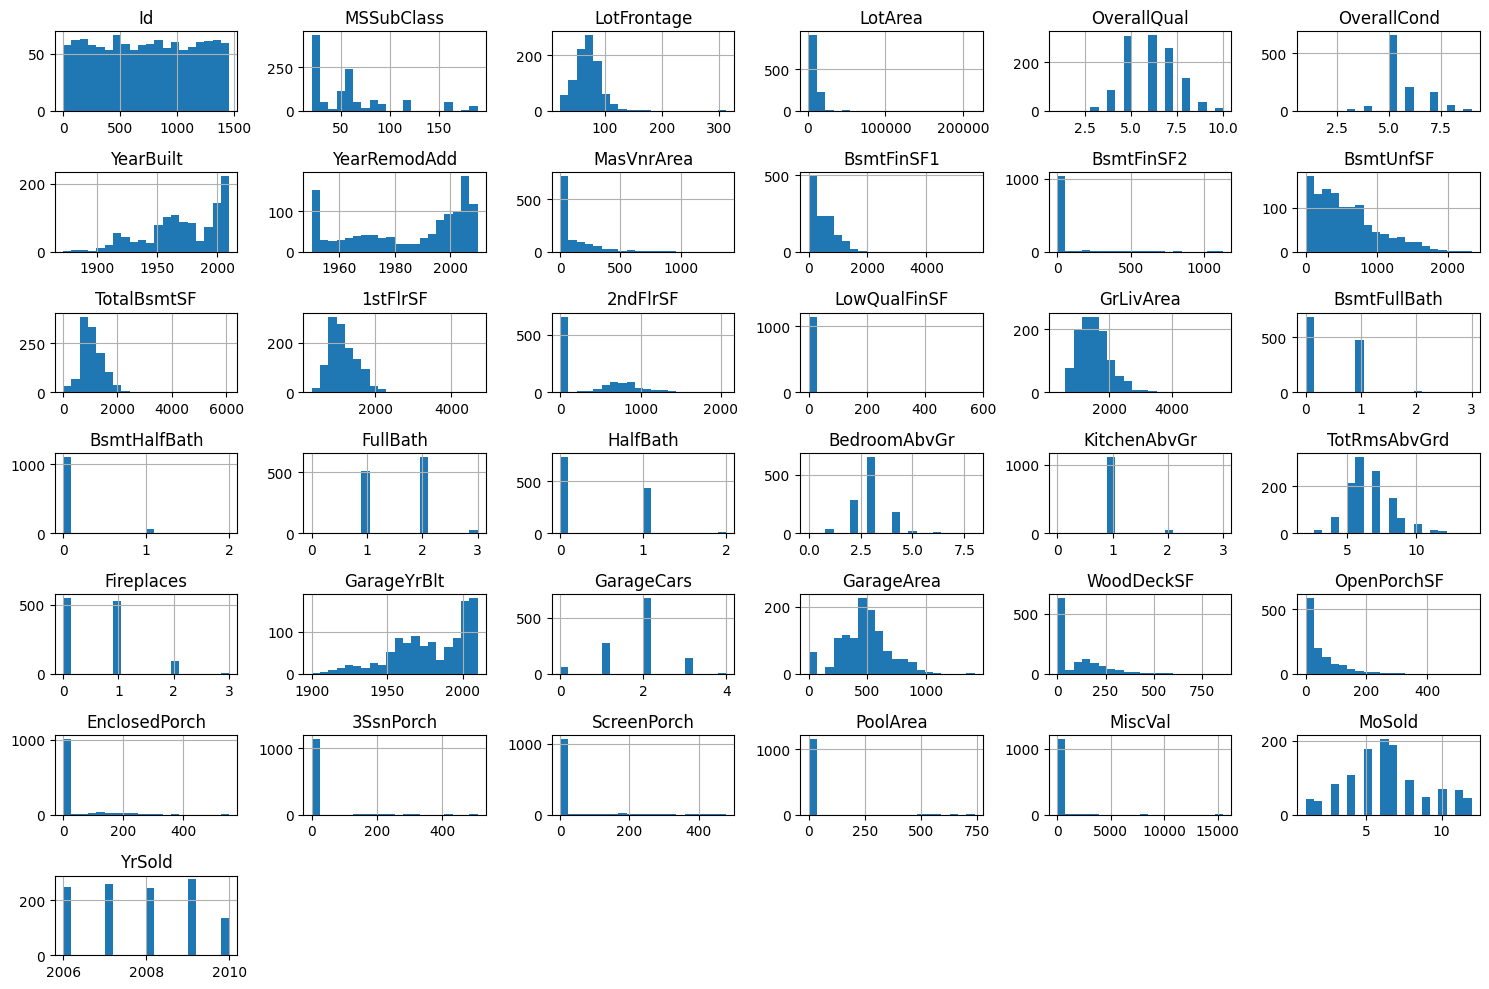

In [350]:
import matplotlib.pyplot as plt

X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Data Cleaning

In [351]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import warnings
from sklearn import set_config

set_config(transform_output="pandas")

In [352]:
na_cat_cols = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature" ]
mode_cat_cols = list(set(cat_cols) - set(na_cat_cols))

target_cols = ["MSZoning", "Street", "Alley", "LotShape", "LandContour", "Utilities", "LotConfig", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "PavedDrive", "MiscFeature", "SaleType", "SaleCondition", "Neighborhood"]
ord_cols = ["LandSlope", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence"]

drop_cols = [
    "Id",
]

target_na_cols = list(set(target_cols) & set(na_cat_cols) - set(drop_cols))
target_mode_cols = list(set(target_cols) & set(mode_cat_cols) - set(drop_cols))

ord_na_cols = list(set(ord_cols) & set(na_cat_cols) - set(drop_cols))
ord_mode_cols = list(set(ord_cols) & set(mode_cat_cols) - set(drop_cols))

num_cols = list(set(num_cols) - set(drop_cols))

In [353]:
cat_set = set(cat_cols)
target_set = set(target_cols)
ord_set = set(ord_cols)

missing = cat_set - (target_set | ord_set)

print("Missing columns:", missing)
duplicates = target_set & ord_set

print("Columns in both:", duplicates)

print(set(na_cat_cols).issubset(set(cat_cols)))

common = set(na_cat_cols) & set(num_cols)
print("Common columns:", common)

Missing columns: set()
Columns in both: set()
True
Common columns: set()


In [354]:
quality_map = {
    "NA": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_cols = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual", "GarageCond",
    "PoolQC"
]


ordinal_map_non_quality = {
    "BsmtExposure": {"NA":0, "No":1, "Mn":2, "Av":3, "Gd":4},

    "BsmtFinType1": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    "BsmtFinType2": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},

    "Functional": {
        "Sal":0, "Sev":1, "Maj2":2, "Maj1":3,
        "Mod":4, "Min2":5, "Min1":6, "Typ":7
    },

    "GarageFinish": {"NA":0, "Unf":1, "RFn":2, "Fin":3},

    "Fence": {"NA":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4},

    "LandSlope": {"Gtl":0, "Mod":1, "Sev":2}
}

ordinal_mappings = {
    "ExterQual": quality_map,
    "ExterCond": quality_map,
    "BsmtQual": quality_map,
    "BsmtCond": quality_map,
    "HeatingQC": quality_map,
    "KitchenQual": quality_map,
    "FireplaceQu": quality_map,
    "GarageQual": quality_map,
    "GarageCond": quality_map,
    "PoolQC": quality_map,

    **ordinal_map_non_quality
}

In [355]:
mapping_keys = set(ordinal_mappings.keys())
ord_set = set(ord_cols)

print(mapping_keys == ord_set)

True


In [356]:
from sklearn.base import BaseEstimator, TransformerMixin

class OrdinalMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col, mapping in self.mappings.items():
            if col in X.columns:
                X[col] = X[col].fillna("NA").map(mapping)

        return X

In [357]:
from category_encoders import TargetEncoder

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

target_na_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encode", TargetEncoder())
])

target_mode_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")), 
    ("encode", TargetEncoder())
])

ord_na_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="NA")), 
    ("encode", OrdinalMapper(ordinal_mappings)) 
])

ord_mode_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")), 
    ("encode", OrdinalMapper(ordinal_mappings)) 
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    
    ("target_na_cols", target_na_pipeline, target_na_cols),
    ("target_mode_cols", target_mode_pipeline, target_mode_cols), 
    
    ("ord_na_cols", ord_na_pipeline, ord_na_cols), 
    ("ord_mode_cols", ord_mode_pipeline, ord_mode_cols), 

    ("drop_cols", "drop", drop_cols)
], remainder="passthrough")

# Feature Engineering

In [358]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["TotalSF"] = (
            X["1stFlrSF"].fillna(0) +
            X["2ndFlrSF"].fillna(0) +
            X["TotalBsmtSF"].fillna(0)
        )

        total_bath = (
            X["FullBath"].fillna(0) +
            0.5 * X["HalfBath"].fillna(0) +
            X["BsmtFullBath"].fillna(0) +
            0.5 * X["BsmtHalfBath"].fillna(0)
        )

        X["TotalBathPerArea"] = total_bath / X["TotalSF"].replace(0, np.nan)
        X["TotalBathPerArea"] = X["TotalBathPerArea"].fillna(0)

        X["HouseAge"] = X["YrSold"].fillna(0) - X["YearBuilt"].fillna(0)

        X["RoomsPerArea"] = X["TotRmsAbvGrd"].fillna(0) / X["TotalSF"].replace(0, np.nan)
        X["RoomsPerArea"] = X["RoomsPerArea"].fillna(0)

        X["RemodAge"] = X["YrSold"].fillna(0) - X["YearRemodAdd"].fillna(0)

        return X

# Feature Selection

In [359]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold):
        self.threshold = threshold
        self.features_to_drop_ = None
        self.selected_features_ = None
        
    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        corr_matrix = X.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        features_to_drop = set()

        for col in upper.columns:
            if any(upper[col] > self.threshold):

                partners = upper.index[upper[col] > self.threshold].tolist()

                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        features_to_drop.add(col)
                    else:
                        features_to_drop.add(partner)

        self.features_to_drop_ = features_to_drop
        self.selected_features_ = [
            col for col in X.columns if col not in features_to_drop
        ]

        return self


    def transform(self, X):
        X = pd.DataFrame(X).copy()

        missing = set(self.selected_features_) - set(X.columns)
        if missing:
            raise ValueError(f"Missing columns in transform: {missing}")

        return X[self.selected_features_]

# RFE

In [360]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import pandas as pd

class RFESelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select):
        self.n_features_to_select = n_features_to_select

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        self.feature_names_ = list(X.columns)

        estimator = LinearRegression()
        self.rfe_ = RFE(estimator=estimator, n_features_to_select=self.n_features_to_select)
        self.rfe_.fit(X, y)

        self.selected_features_ = [
            f for f, s in zip(self.feature_names_, self.rfe_.support_) if s
        ]

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_)
        return X[self.selected_features_]

# Linear Regression

In [361]:
import mlflow
import json
import numpy as np
import skops.io as sio
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import pickle

full_pipeline = Pipeline([
    ("feature_eng", FeatureEngineer()),
    ("preprocess", preprocessor),
    ("corr_filter", CorrelationFilter(threshold=0.8)),
    ("RFE", RFESelector(n_features_to_select=65)),
    ("model", LinearRegression())    
])

mlflow.set_experiment("house_prices_full_pipeline")

with mlflow.start_run(run_name="full_pipeline_v8"):
    mlflow.log_param("num_cols", num_cols)
    mlflow.log_param("cat_cols", cat_cols)
    mlflow.log_param("na_cat_cols", na_cat_cols)
    mlflow.log_param("mode_cat_cols", mode_cat_cols)
    mlflow.log_param("target_cols", target_cols)
    mlflow.log_param("ord_cols", ord_cols)
    mlflow.log_param("drop_cols", drop_cols)

    mlflow.log_param("target_na_cols", target_na_cols)
    mlflow.log_param("target_mode_cols", target_mode_cols)
    mlflow.log_param("ord_na_cols", ord_na_cols)
    mlflow.log_param("ord_mode_cols", ord_mode_cols)

    mlflow.log_param("feature_engineering", "TotalSF, TotalBathPerArea, HouseAge, RoomsPerArea, RemodAge")
    
    mlflow.log_param("num_pipeline", "median_impute + standard_scaler")

    mlflow.log_param("model", "LinearRegression")

    mlflow.log_param("pipeline_steps", [
    "FeatureEngineer",
    "Preprocessor",
    "CorrelationFilter",
    "RFE",
    "LinearRegression"
    ])

    mlflow.log_param("RFE", 65)

    
    full_pipeline.fit(X_train, y_train)
    preds = full_pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print("RMSE:", rmse)
    
    mlflow.log_metric("rmse", rmse)
    
    corr_filter = full_pipeline.named_steps["corr_filter"]
    
    mlflow.log_param("corr_threshold", corr_filter.threshold)
    mlflow.log_param("num_features_after_corr", len(corr_filter.selected_features_))
    mlflow.log_param("num_dropped_corr", len(corr_filter.features_to_drop_))
    
    mlflow.log_param("dropped_corr_features", json.dumps(list(corr_filter.features_to_drop_)))
    
    with open("model.pkl", "wb") as f:
        pickle.dump(full_pipeline, f)
    mlflow.log_artifact("model.pkl")
    
    
    mlflow.sklearn.log_model(
        sk_model=full_pipeline,
        artifact_path="model",
        registered_model_name="house_prices_model"
    )
    

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


RMSE: 0.13642517283398164


2026/04/13 11:09:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:10:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_prices_model' already exists. Creating a new version of this model...
2026/04/13 11:10:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_prices_model, version 3
Created version '3' of model 'house_prices_model'.


🏃 View run full_pipeline_v8 at: https://dagshub.com/lmars23/ml_assignment_1.mlflow/#/experiments/2/runs/69b14988b118423188c7dac4c2b73d26
🧪 View experiment at: https://dagshub.com/lmars23/ml_assignment_1.mlflow/#/experiments/2


# Decision Tree

In [362]:
import mlflow
import numpy as np
import pandas as pd
import pickle

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error


full_pipeline = Pipeline([
    ("feature_eng", FeatureEngineer()),
    ("preprocess", preprocessor),
    ("corr_filter", CorrelationFilter(threshold=0.8)),
    ("model", DecisionTreeRegressor(random_state=42))
])


param_grid_dt = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 5],
    "model__criterion": ["squared_error", "friedman_mse"],
    "model__max_features": [None, "sqrt", "log2"]
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_dt,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1,
    verbose=2
)


mlflow.set_experiment("house_prices_decision_tree")

with mlflow.start_run(run_name="DecisionTree_full_search"):

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    best_cv_rmse = -grid_search.best_score_

    print("Best CV RMSE:", best_cv_rmse)
    print("Best params:", grid_search.best_params_)

    preds = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print("Test RMSE:", rmse)

    mlflow.log_metric("best_cv_rmse", best_cv_rmse)
    mlflow.log_metric("test_rmse", rmse)

    for k, v in grid_search.best_params_.items():
        mlflow.log_param(k, v)


    results = pd.DataFrame(grid_search.cv_results_)
    results.to_csv("dt_results.csv", index=False)
    mlflow.log_artifact("dt_results.csv")

    with open("best_dt.pkl", "wb") as f:
        pickle.dump(best_model, f)
    mlflow.log_artifact("best_dt.pkl")

# Random Forest

In [363]:
import mlflow
import numpy as np
import pandas as pd
import pickle

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error


full_pipeline = Pipeline([
    ("feature_eng", FeatureEngineer()),
    ("preprocess", preprocessor),
    ("corr_filter", CorrelationFilter(threshold=0.8)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid_dt = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 5],
    "model__max_features": [None, "sqrt", "log2"]
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_dt,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1,
    verbose=2
)


mlflow.set_experiment("house_prices_random_forest")

with mlflow.start_run(run_name="RandomForest_full_search"):

    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    best_cv_rmse = -grid_search.best_score_
    
    print("Best CV RMSE:", best_cv_rmse)
    print("Best params:", grid_search.best_params_)
    
    preds = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print("Test RMSE:", rmse)

    mlflow.log_metric("best_cv_rmse", best_cv_rmse)
    mlflow.log_metric("test_rmse", rmse)

    for k, v in grid_search.best_params_.items():
        mlflow.log_param(k, v)

    results = pd.DataFrame(grid_search.cv_results_)
    results.to_csv("dt_results.csv", index=False)
    mlflow.log_artifact("dt_results.csv")

    with open("best_dt.pkl", "wb") as f:
        pickle.dump(best_model, f)
    mlflow.log_artifact("best_dt.pkl")

test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
preds = best_model.predict(test)
preds = np.expm1(preds)

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": preds
})
submission.to_csv("submission.csv", index=False)